In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip "/content/drive/MyDrive/EVSE.zip" -d /content/drive/MyDrive/

In [ ]:
import pandas as pd
df_power = pd.read_csv(
    "/content/drive/MyDrive/EVSE/Power Consumption/EVSE-B-PowerCombined.csv"
)

print(df_power.shape)
print(df_power.columns)
df_power.head()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load your cleaned dataset (replace with your actual path)
df = pd.read_csv('/content/drive/MyDrive/EVSE/Power Consumption/EVSE-B-PowerCombined.csv')

# Encode target label (e.g., 'attack' vs 'benign')
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

# Select features (numerical columns) and target
X = df.drop(columns=['Label', 'Attack', 'State', 'interface', 'time', 'Attack-Group'])
y = df['Label']

# 80-20 Train-Test Split as requested
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale features for models like MLP and LSTM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load the Power Consumption dataset
# Based on your notebook paths:
df_power = pd.read_csv("/content/drive/MyDrive/EVSE/Power Consumption/EVSE-B-PowerCombined.csv")

# 2. Preprocessing
# Select numerical features relevant to power consumption
features = ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW']
X = df_power[features]

# Convert 'Label' to numeric for evaluation (attack = -1, benign = 1)
# Isolation Forest predicts -1 for anomalies (attacks) and 1 for normal data
y = df_power['Label'].apply(lambda x: -1 if x == 'attack' else 1)

# 3. 80-20 Train-Test Split [as requested]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale features (recommended for better performance with continuous power data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and Train Isolation Forest
# contamination='auto' or set to the known ratio of attacks if known
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(X_train_scaled)

# 5. Prediction and Evaluation
y_pred = iso_forest.predict(X_test_scaled)

print("Isolation Forest Results for Power Consumption:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Attack (Anomaly)', 'Benign (Normal)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

Isolation Forest Results for Power Consumption:
Accuracy: 0.2980

Classification Report:
                  precision    recall  f1-score   support

Attack (Anomaly)       0.80      0.26      0.39     20065
 Benign (Normal)       0.10      0.56      0.17      2995

        accuracy                           0.30     23060
       macro avg       0.45      0.41      0.28     23060
    weighted avg       0.71      0.30      0.36     23060

Confusion Matrix:
[[ 5189 14876]
 [ 1312  1683]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Assuming X_train_scaled, X_test_scaled, y_train, y_test from cell l2_jCoVRmeg0 are available and suitable
# (i.e., y_train and y_test are 0/1 encoded and X_scaled are the features)

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_scaled)

print("Random Forest Classifier Results for Power Consumption:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Attack']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"Confusion Matrix:\n{cm_rf}")

Random Forest Classifier Results for Power Consumption:
Accuracy: 0.9431

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97     20065
      Attack       0.85      0.69      0.76      2995

    accuracy                           0.94     23060
   macro avg       0.90      0.83      0.86     23060
weighted avg       0.94      0.94      0.94     23060

Confusion Matrix:
[[19690   375]
 [  938  2057]]


In [ ]:
import pandas as pd
df_power = pd.read_csv("/content/drive/MyDrive/EVSE/Power Consumption/EVSE-B-PowerCombined.csv")

# 1. Print the data types of all columns
print("\n--- DataFrame Info ---")
df_power.info()

# 2. Create a list called numerical_cols
numerical_cols = df_power.select_dtypes(include=['number']).columns.tolist()

# 3. Create a list called categorical_cols
categorical_cols = df_power.select_dtypes(include=['object']).columns.tolist()

# 4. Print both lists
print("\nNumerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

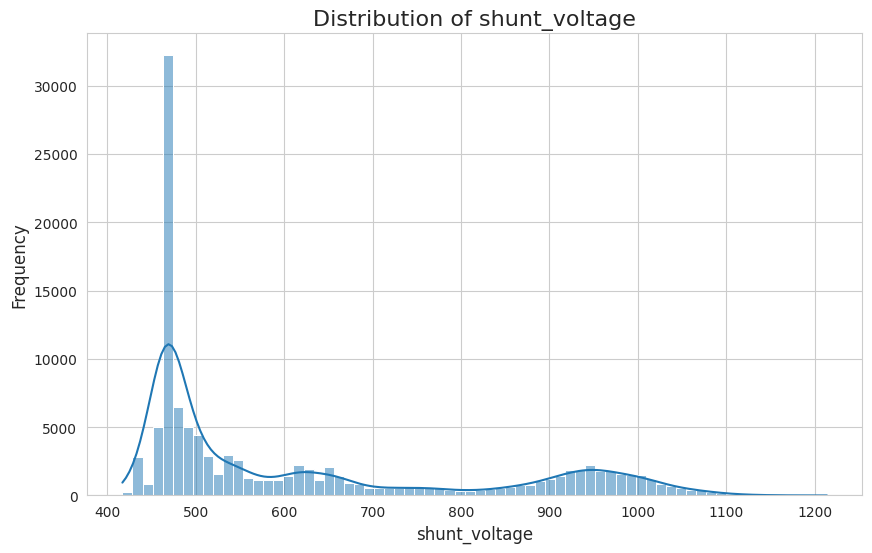

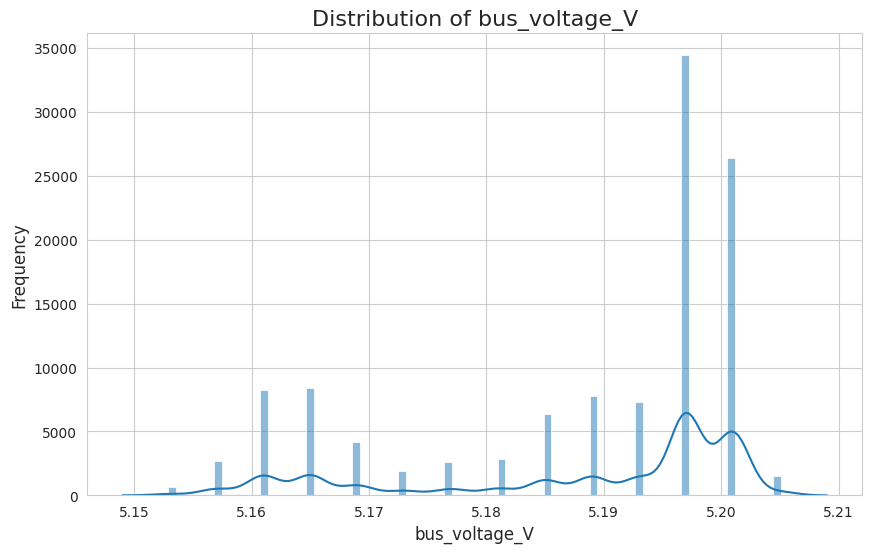

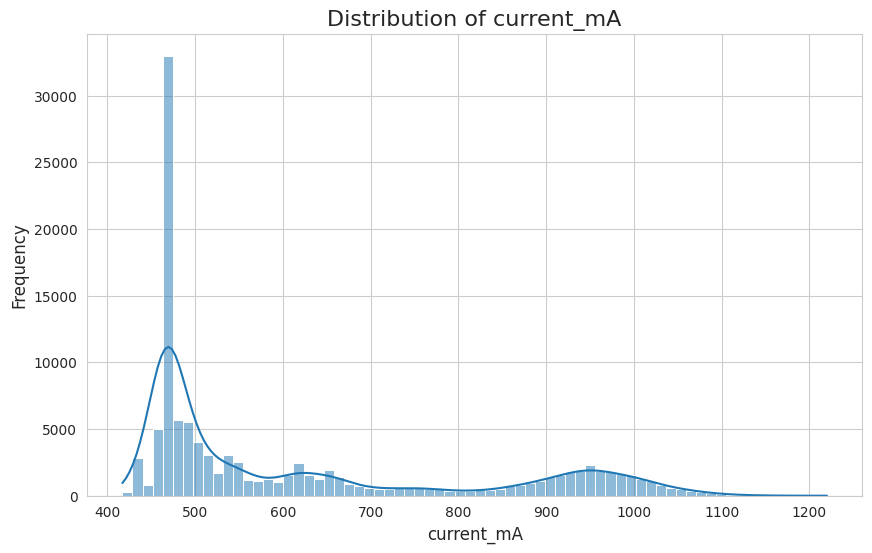

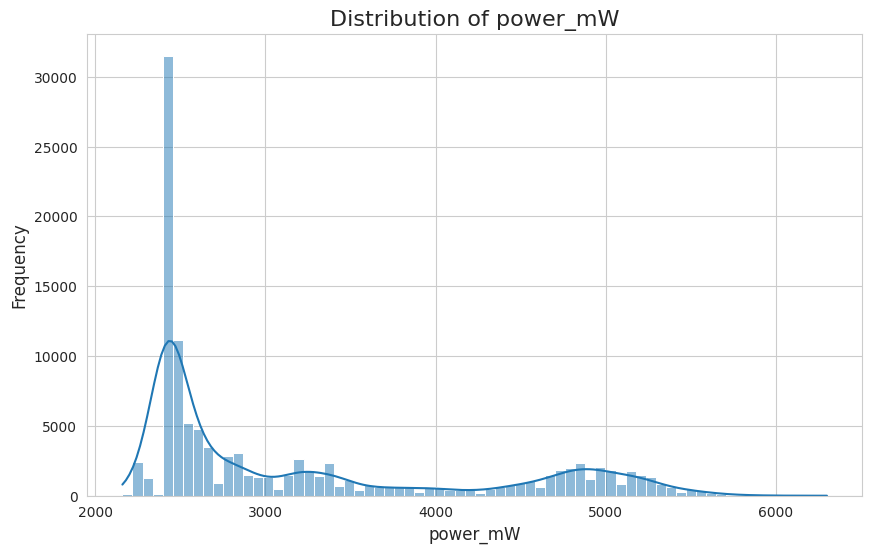

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_style("whitegrid")

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
    sns.histplot(df_power[col], kde=True) # Use kde=True to show kernel density estimate
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()

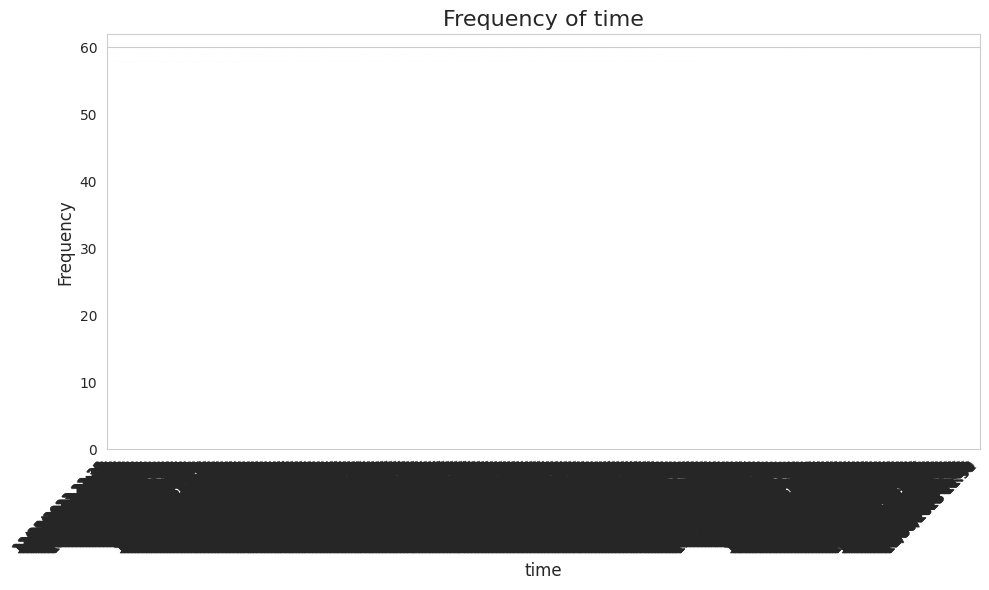

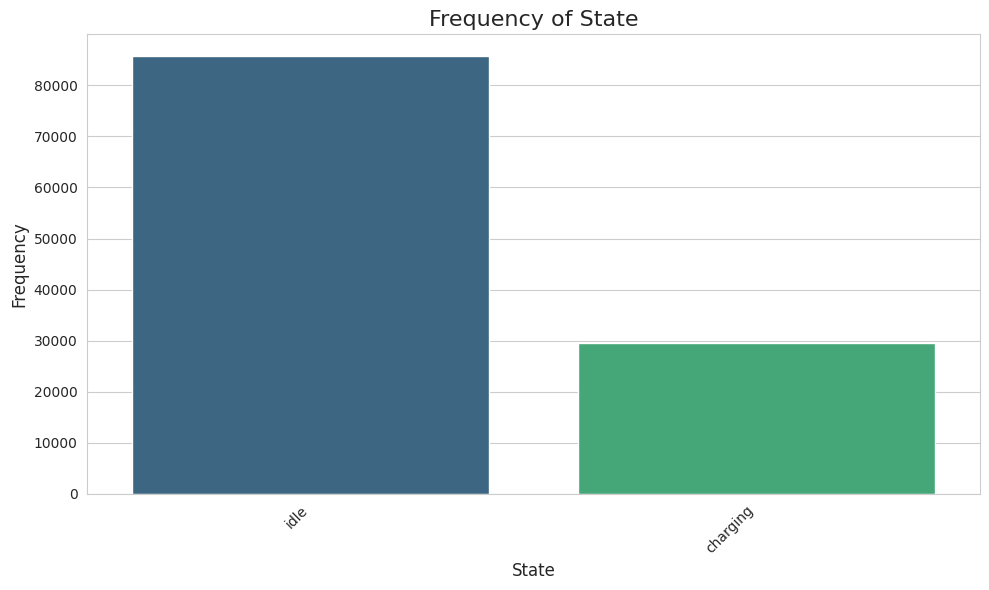

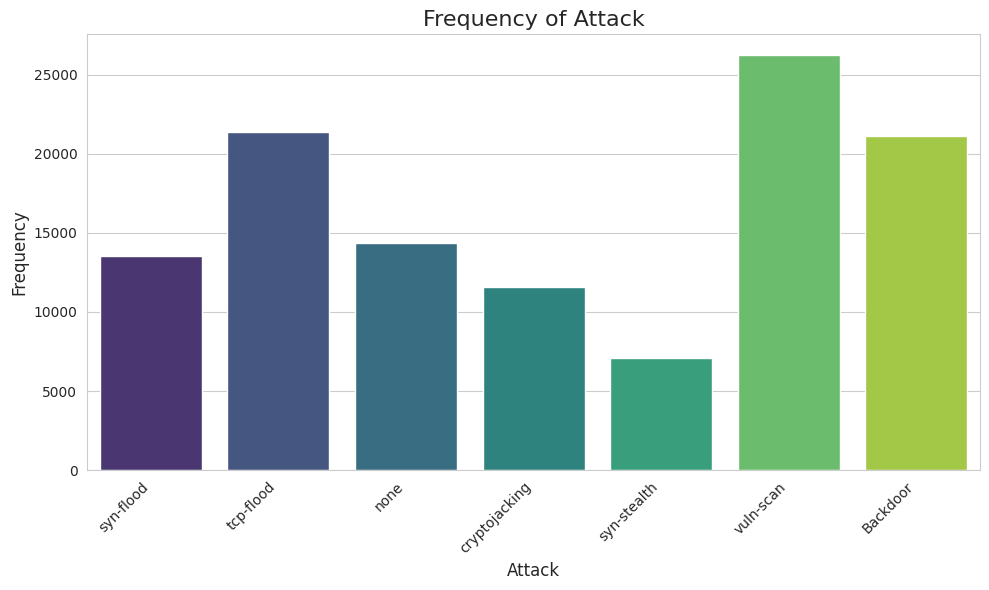

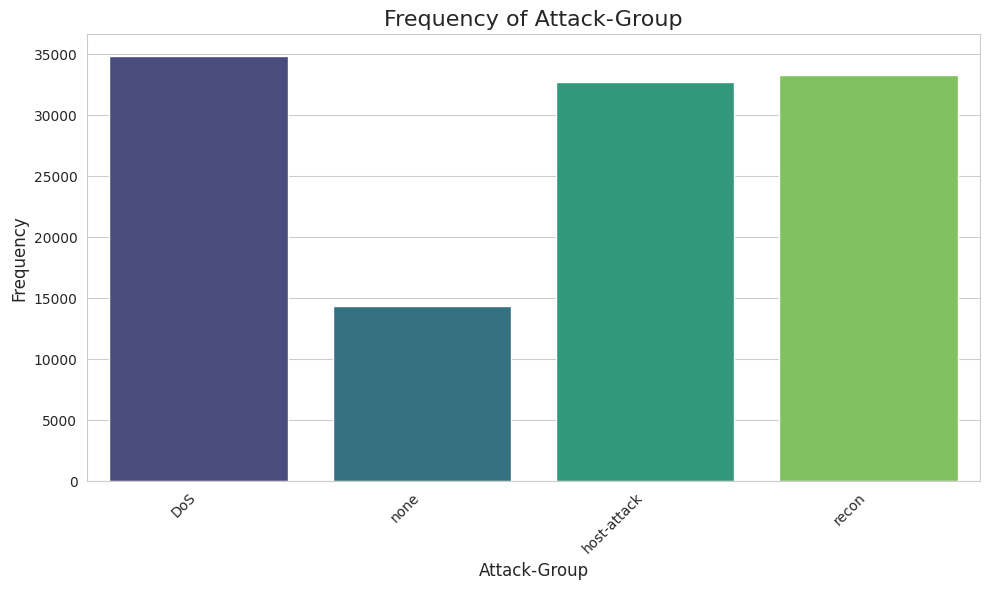

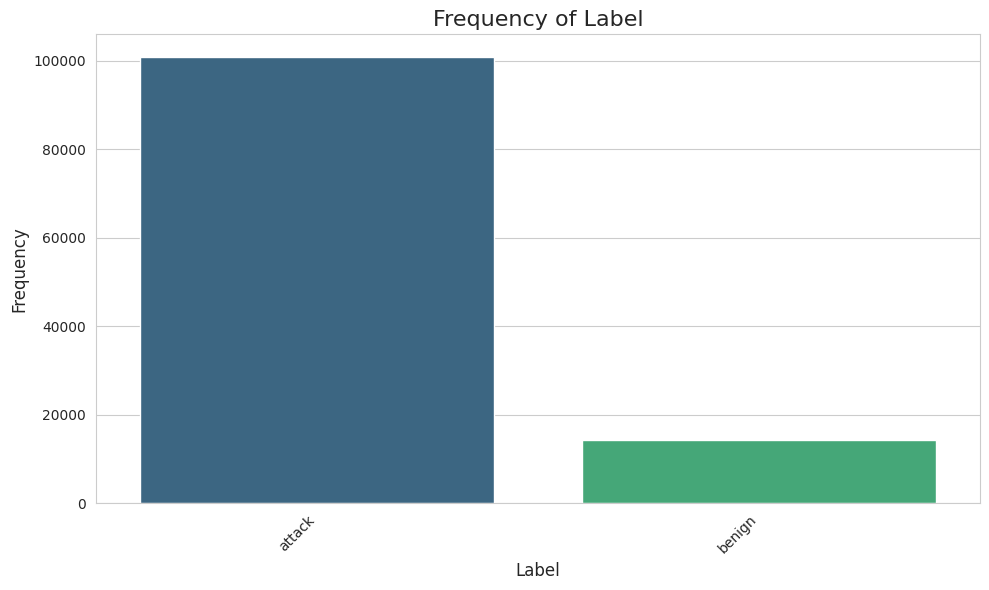

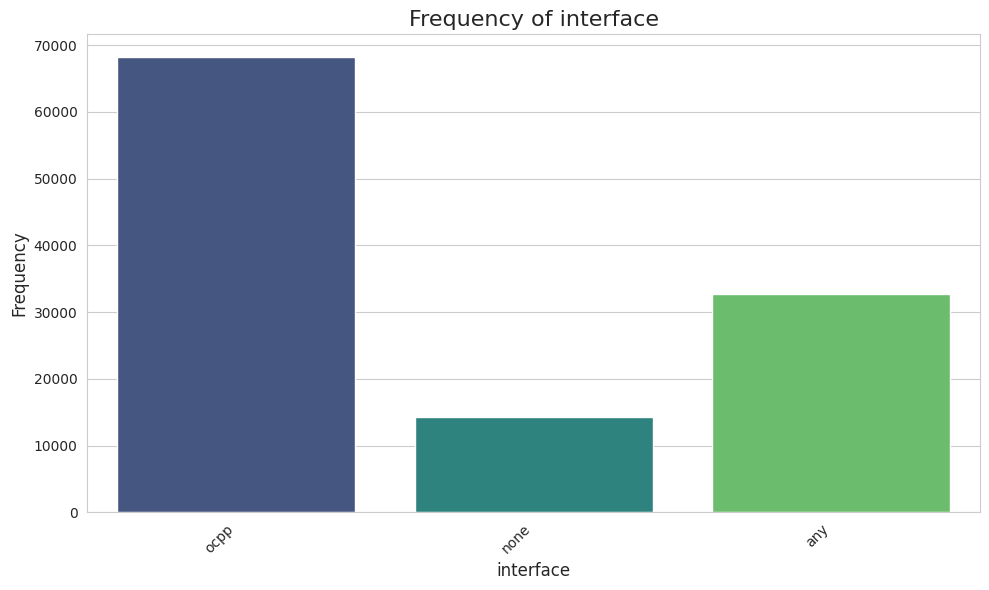

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_style("whitegrid")

# Iterate through categorical columns and create bar plots of value counts
for col in categorical_cols:
    plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
    sns.countplot(data=df_power, x=col, palette='viridis')
    plt.title(f'Frequency of {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if categories are long
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

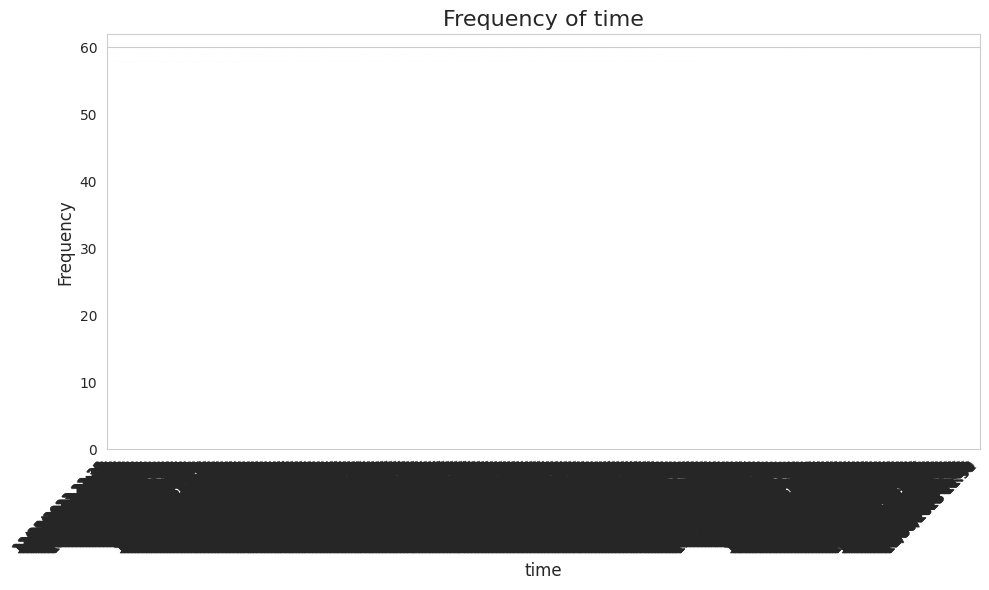

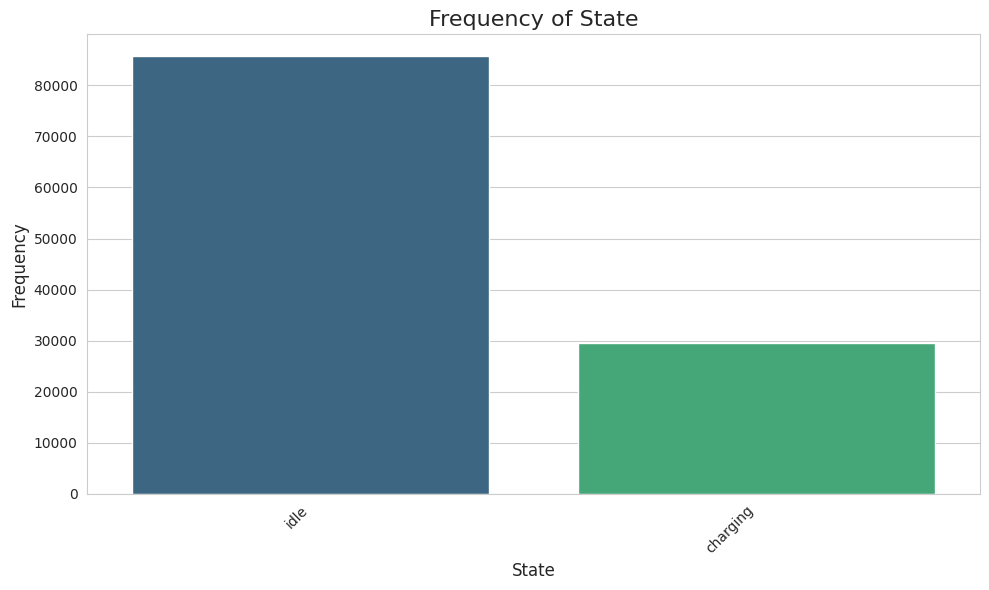

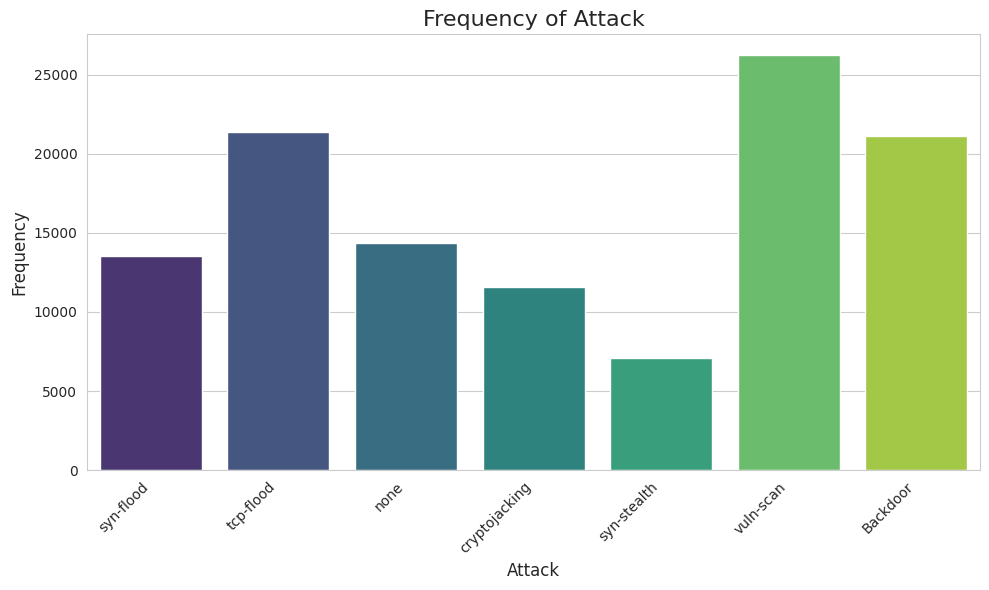

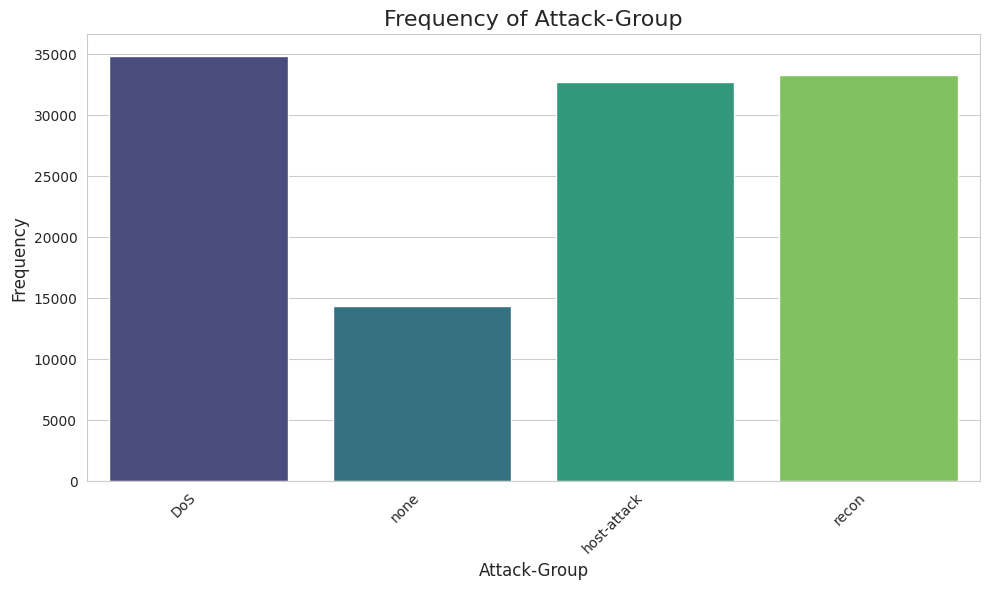

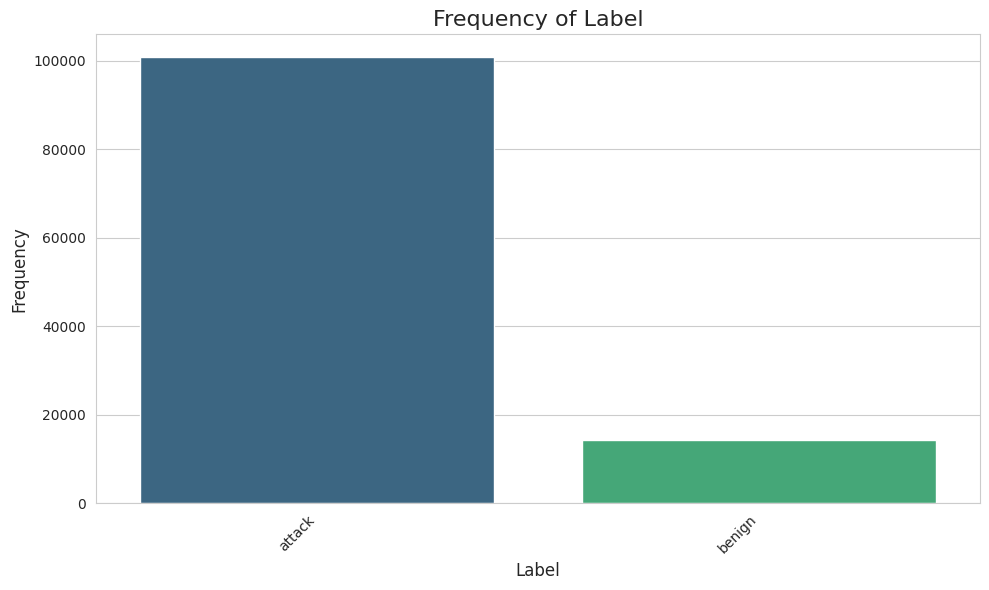

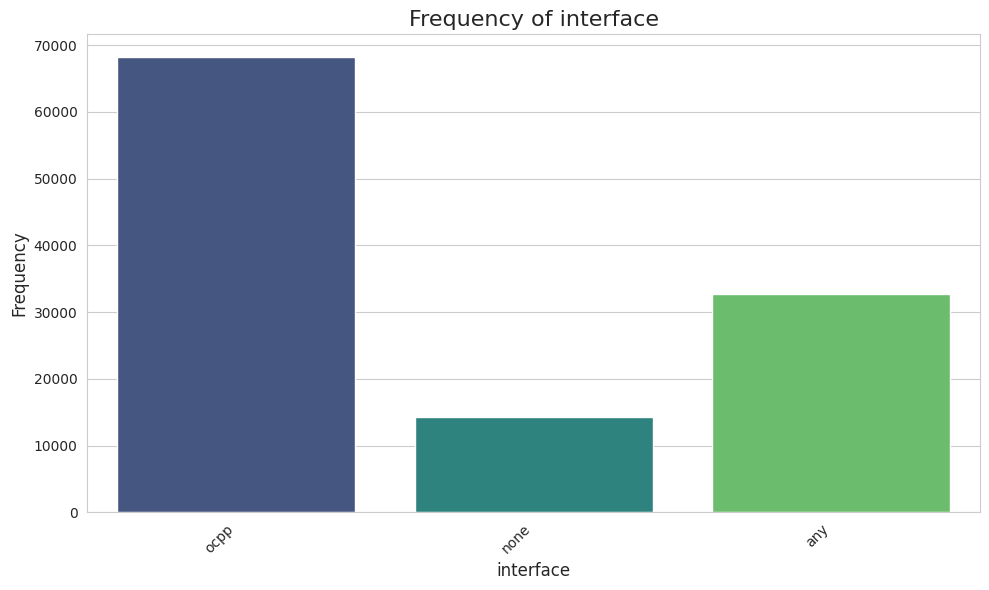

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_style("whitegrid")

# Iterate through categorical columns and create bar plots of value counts
for col in categorical_cols:
    plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
    sns.countplot(data=df_power, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Frequency of {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if categories are long
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()